# Hospital Readmission Prediction

**Objective:**  
Build a baseline machine learning model to predict whether a patient will be readmitted to the hospital using demographic, clinical, and visit-related features.

In [9]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
# Load dataset
raw_dir = "../data/raw"
csv_path = os.path.join(raw_dir, [f for f in os.listdir(raw_dir) if f.endswith(".csv")][0])

df = pd.read_csv(csv_path)

# Create target variable
df["readmitted_flag"] = df["readmitted"].map({"no": 0, "yes": 1})

df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted,readmitted_flag
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no,0
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no,0
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes,1
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes,1
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no,0


In [4]:
y = df["readmitted_flag"]
x = df.drop(columns = ["readmitted", "readmitted_flag"])

In [5]:
num_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x.select_dtypes(include=["object"]).columns.tolist()

In [11]:
# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("log_reg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Fit model
model.fit(x_train, y_train)

# Predictions
pred = model.predict(x_test)
proba = model.predict_proba(x_test)[:, 1]

# Results
print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.62      0.71      0.66      2649
           1       0.60      0.50      0.55      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.60      5000
weighted avg       0.61      0.61      0.61      5000

ROC AUC: 0.6450720390943896


### Handling Class Imbalance

Because hospital readmissions are less frequent than non-readmissions, the dataset is slightly imbalanced.
To address this, the logistic regression model was trained using class-weight balancing.

This approach increases the importance of readmitted cases during training and helps improve recall for the positive class.


## Model Interpretation

The baseline logistic regression model achieves a ROC AUC of approximately 0.64.  
This result provides a reasonable benchmark and highlights the difficulty of predicting hospital readmissions using tabular clinical data.


### Baseline Model Results

The logistic regression baseline achieves a ROC AUC of approximately 0.65, indicating moderate ability to distinguish between patients who are readmitted and those who are not.  

Recall for the readmitted class is lower than for the non readmitted class, which suggests the model struggles to capture all readmission cases. This is expected for a simple baseline and motivates further model improvements.


### Class Balance

The target variable is slightly imbalanced, with fewer readmission cases than non readmission cases. Stratified sampling was used during train test split to preserve the class distribution.


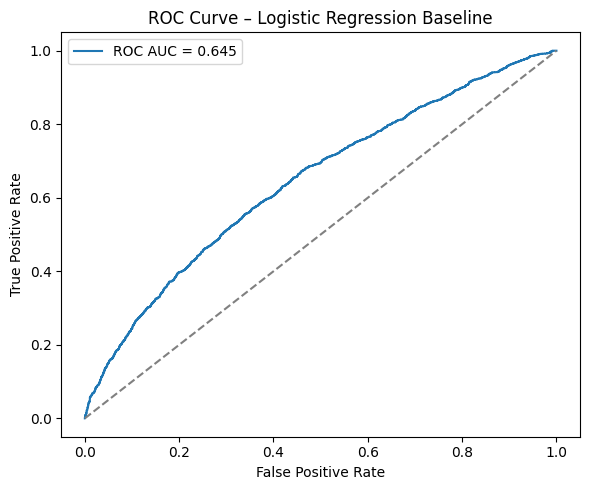

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Extract feature names after preprocessing
feature_names = model.named_steps["preprocess"].get_feature_names_out()

coefficients = model.named_steps["log_reg"].coef_[0]

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .sort_values(by="coefficient", key=abs, ascending=False)
)

importance_df.head(15)


,feature,coefficient
40,cat__diag_3_Missing,-0.584121
5,num__n_inpatient,0.382280
6,num__n_emergency,0.249278
21,cat__diag_1_Diabetes,0.246074
24,cat__diag_1_Missing,-0.228418
52,cat__diabetes_med_no,-0.223563
12,cat__age_[90-100),-0.214449
32,cat__diag_2_Missing,0.209736
19,cat__medical_specialty_Surgery,-0.206360
49,cat__A1Ctest_normal,-0.179327


In [ ]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 4))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.title("Top Features by Absolute Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
